In [4]:
!cd /media/mengh/SharedData/zhanh/synth-proxy_v1 && \
python src/sfproxy/export_dataset_pkl.py \
  --config-name export_salamander_piano \
  dataset_size=2000 \
  seed_offset=1 \
  start_index=0 end_index=2000


[2026-03-23 16:41:39,723][__main__][INFO] - Export configs
[2026-03-23 16:41:39,723][__main__][INFO] - instrument: salamander_piano
[2026-03-23 16:41:39,723][__main__][INFO] - instrument_type: sf2
[2026-03-23 16:41:39,723][__main__][INFO] - sf2_path: /media/mengh/SharedData/zhanh/202601_midisemi_data/soundfront/SalamanderGrandPiano-SF2-V3+20200602/SalamanderGrandPiano-V3+20200602.sf2
[2026-03-23 16:41:39,723][__main__][INFO] - bank: 0
[2026-03-23 16:41:39,723][__main__][INFO] - program: 0
[2026-03-23 16:41:39,723][__main__][INFO] - polyphony: 64
[2026-03-23 16:41:39,723][__main__][INFO] - gain_db: -6.0
[2026-03-23 16:41:39,723][__main__][INFO] - dataset_size: 2000
[2026-03-23 16:41:39,723][__main__][INFO] - virtual_dataset_size: 2000
[2026-03-23 16:41:39,723][__main__][INFO] - start_index: 0
[2026-03-23 16:41:39,723][__main__][INFO] - end_index: 2000
[2026-03-23 16:41:39,723][__main__][INFO] - seed_offset: 1
[2026-03-23 16:41:39,723][__main__][INFO] - sr: 22050
[2026-03-23 16:41:39,723

In [ ]:
!python src/sfproxy/export_dataset_pkl.py \
  --config-name export_salamander_piano \
  sampler_preset=realism \
  sampler_velo_present=true

In [ ]:
# 生成 MAESTRO 统计：
!cd /media/mengh/SharedData/zhanh/202601_midisemi/data_analysis
!python dataset_midi_stats.py \
  --dataset MAESTRO_v3.0.0 \
  --root /path/to/maestro \
  --json-out-dir stats/midi_sampler \
  --output-dir figures/midi_sampler_stats \
  --no-show


In [ ]:
# 生成 GuitarSet 统计：
!cd /media/mengh/SharedData/zhanh/202601_midisemi/data_analysis
!python dataset_midi_stats.py \
  --dataset GuitarSet \
  --root /path/to/guitarset \
  --json-out-dir stats/midi_sampler \
  --output-dir figures/midi_sampler_stats \
  --no-show

In [ ]:
import os
os.environ["WANDB_SILENT"] = "true"

!python src/sfproxy/train.py \
  --config-name train_piano_cov_v1


In [3]:
!python src/sfproxy/eval_velocity_recovery.py \
  --config-name velocity_recovery \
  ckpt_path=/media/mengh/SharedData/zhanh/202601_midisemi_data/synth-proxy_v1/proxy/logs/sfproxy/sfproxy_train_2026-03-24_16-47-00/checkpoints/sfproxy_train_e199_loss0.0868.ckpt \
  device=cuda \
  indomain.num_segments=50 \
  stress.num_segments=50


[2026-03-27 13:43:50,272][__main__][INFO] - [rank: 0] Running sfproxy velocity recovery test
[2026-03-27 13:43:50,273][__main__][INFO] - [rank: 0] ckpt=sfproxy_train_e199_loss0.0868.ckpt | device=cuda | steps=120 | lr=0.03 | init=mid
[2026-03-27 13:43:50,273][__main__][INFO] - [rank: 0] instrument=salamander_piano | sf2=SalamanderGrandPiano-V3+20200602.sf2 | sr=22050 | seg_len=2.00s | nmax=64
[2026-03-27 13:43:50,273][__main__][INFO] - [rank: 0] indomain: segments=50 | polyphony<=16 | chord_prob=0.25 | ioi=[0.03, 0.35]
[2026-03-27 13:43:50,273][__main__][INFO] - [rank: 0] stress: segments=50 | polyphony<=32 | chord_prob=0.65 | ioi=[0.01, 0.15]
[2026-03-27 13:43:50,273][__main__][INFO] - [rank: 0] metrics: velocity errors reported in MIDI [0,127]; model inputs remain normalized internally
indomain: 100%|█| 50/50 [00:32<00:00,  1.53it/s, mae127=10.31, gain=70.5%, feat=
stress: 100%|█| 50/50 [00:38<00:00,  1.29it/s, mae127=17.52, gain=48.2%, feat=0.
[2026-03-27 13:45:02,492][__main__][INF

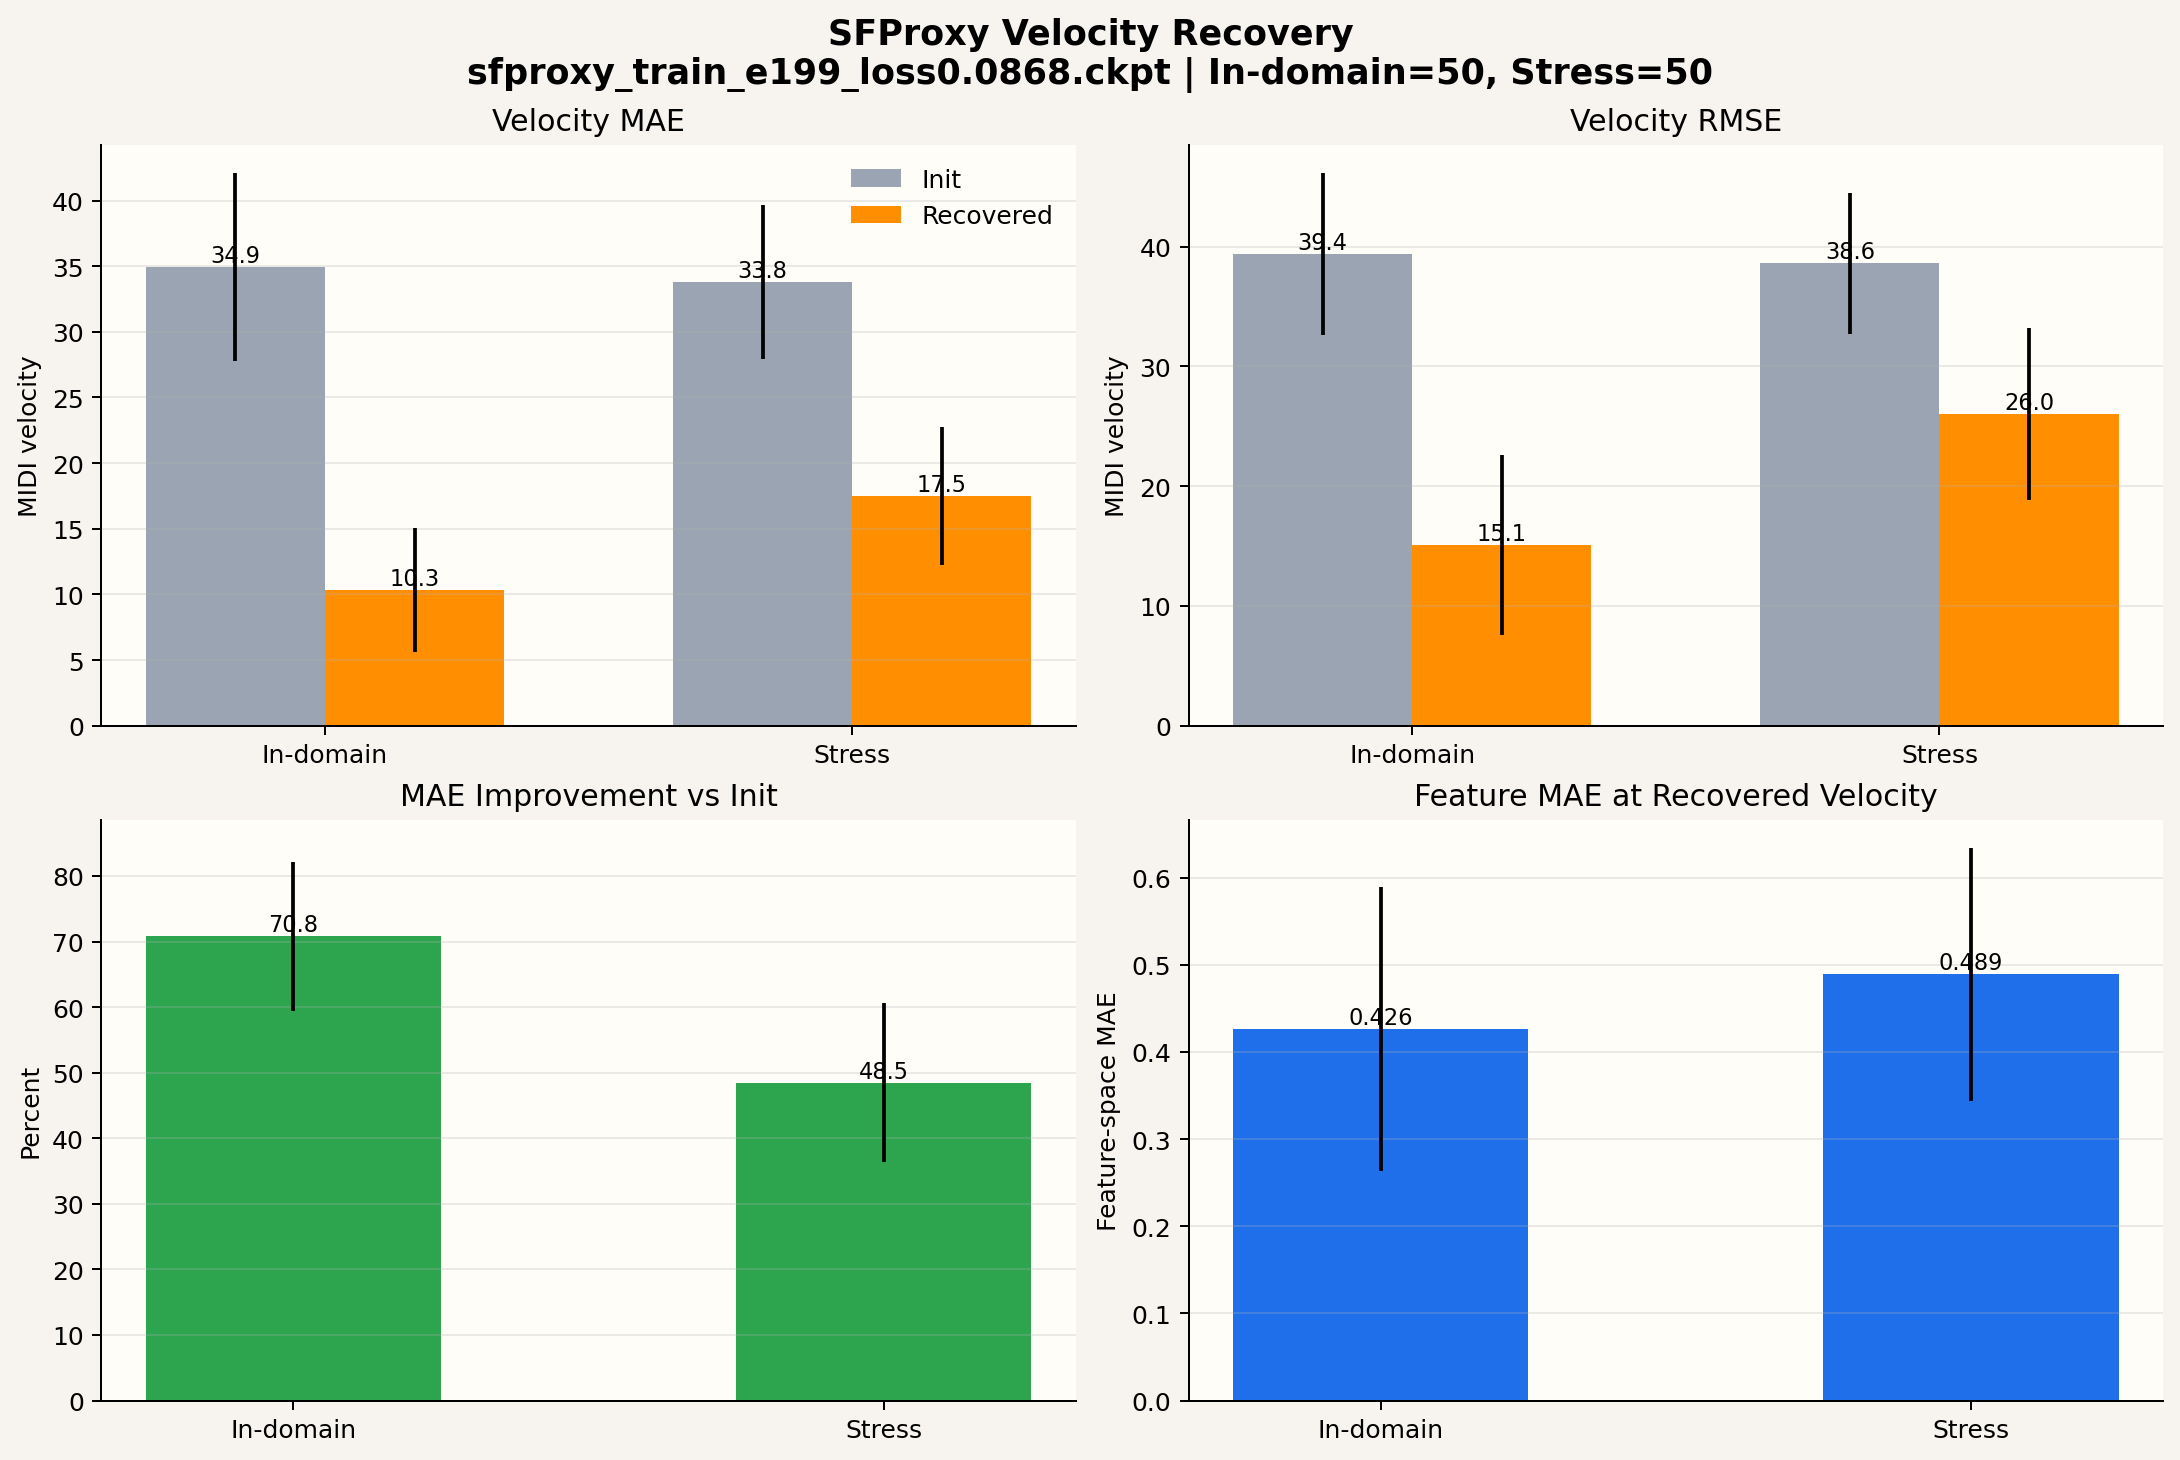

In [4]:
from IPython.display import Image, display

display(Image("/media/mengh/SharedData/zhanh/synth-proxy_v1/outputs/sfproxy/sfproxy_velocity_recovery_2026-03-27_13-43-50/sfproxy_train_e199_loss0.0868_velocity_recovery_summary.png"))
